In [2]:
from graph2mat4abn.tools.import_utils import load_config, get_object_from_module
from graph2mat4abn.tools.tools import get_basis_from_structures_paths, get_kwargs, load_model
from graph2mat4abn.tools.scripts_utils import get_model_dataset, init_mace_g2m_model
from graph2mat4abn.tools.script_plots import update_loss_plots, plot_grad_norms
from torch_geometric.data import DataLoader
from graph2mat4abn.tools.scripts_utils import generate_g2m_dataset_from_paths
from graph2mat4abn.tools.notebook_utils import add_dotdot_to_str
from pathlib import Path
from mace.modules import MACE, RealAgnosticResidualInteractionBlock
from graph2mat.models import MatrixMACE
from graph2mat.bindings.e3nn import E3nnGraph2Mat
import torch
import warnings
from graph2mat import BasisTableWithEdges

warnings.filterwarnings("ignore", message="The TorchScript type system doesn't support")
warnings.filterwarnings("ignore", message=".*is not a known matrix type key.*")

from joblib import dump, load
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sisl
import pickle

def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

/home/ICN2/alapena/miniconda3/envs/tbplas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ICN2/alapena/miniconda3/envs/tbplas/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torc

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [3]:
# Select the model to evaluate
model_dir = Path("../results/correctzeroesissue2") 
model_name = "train_best_model.tar"

# Directory to save the results
split = Path(model_name).parts[0].split("_")[0]
savedir = Path(f"../a-plots/{model_dir.parts[-1]}_{split}")

In [4]:
# config = load_config(model_dir / "config.yaml")

# # Basis generation (needed to initialize the model)
# train_paths, val_paths = get_model_dataset(model_dir, verbose=False)

# # We have to add "../" to the relative paths because we are in notebooks/
# train_paths = [Path(add_dotdot_to_str(p)) for p in train_paths]
# val_paths = [Path(add_dotdot_to_str(p)) for p in val_paths]

# paths_basis = train_paths + val_paths
# basis = get_basis_from_structures_paths(paths_basis, verbose=True, num_unique_z=config["dataset"].get("num_unique_z", None))
# table = BasisTableWithEdges(basis)

# print("Initializing model...")
# model, optimizer, lr_scheduler, loss_fn = init_mace_g2m_model(config, table)

# # Load the model
# model_path = model_dir / model_name
# model, checkpoint, optimizer, lr_scheduler = load_model(model, optimizer, model_path, lr_scheduler=None, initial_lr=None, device='cpu')
# history = checkpoint["history"]
# print(f"Loaded model in epoch {checkpoint["epoch"]} with training loss {checkpoint["train_loss"]} and validation loss {checkpoint["val_loss"]}.")

In [15]:
# Structure
# Path('../dataset/SHARE_OUTPUTS_2_ATOMS/52b6-d4b4-4aa1-bf10-8c7d44c978d3'), 
# Path('../dataset/SHARE_OUTPUTS_8_ATOMS/02e5-66b7-491e-a2a9-492390da1112'), #hBN
# Path('../dataset/SHARE_OUTPUTS_8_ATOMS/e0f4-41e6-4ebc-a38b-f41adc8a7e1f'), #cBN

path = Path('../dataset/SHARE_OUTPUTS_8_ATOMS/e0f4-41e6-4ebc-a38b-f41adc8a7e1f')

# Load bands and plot

In [16]:
bands_dir = model_dir / "bands"
n_atoms = path.parts[-2].split("_")[-2]
structure = path.parts[-1]
filename_true = f"{n_atoms}atm_{structure}_bands_true.npz"
filename_pred = f"{n_atoms}atm_{structure}_bands_pred.npz"

loaded = np.load(bands_dir / filename_true)
k_idx_true = loaded["k_idx"]
k_label_true = loaded["k_label"]
k_len_true = loaded["k_len"]
bands_true = loaded["bands"]

loaded = np.load(bands_dir / filename_pred)
k_idx_pred = loaded["k_idx"]
k_label_pred = loaded["k_label"]
k_len_pred = loaded["k_len"]
bands_pred = loaded["bands"]

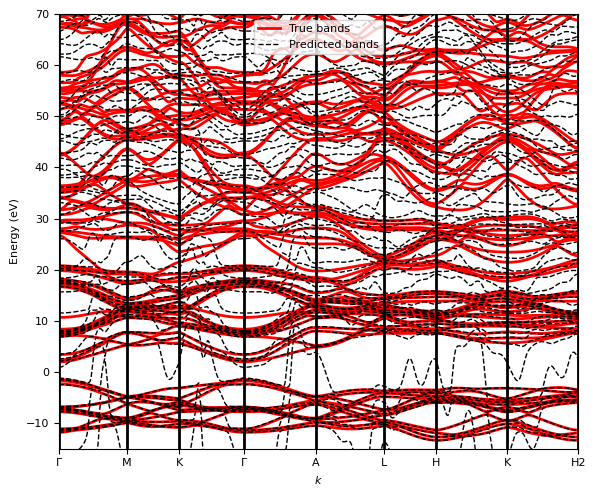

(<Figure size 600x500 with 1 Axes>, <Axes: xlabel='$k$', ylabel='Energy (eV)'>)

In [17]:
def plot_bands_matplotlib(k_len, bands, k_idx, k_label,
                          predicted_bands=None, filepath=None,
                          ylim=None, fermi_lvl=None, legend_loc=None):
    k_len = np.asarray(k_len)
    bands = np.asarray(bands)
    assert bands.ndim == 2, "bands must be (n_kpoints, n_bands)"

    fig, ax = plt.subplots(figsize=(6, 5), facecolor="white")
    ax.set_facecolor("white")

    # True bands: label only on the first column
    ax.plot(k_len, bands[:, 0], color="red", lw=2, label="True bands")
    ax.plot(k_len, bands[:, 1:], color="red", lw=2)  # no label

    # Predicted bands
    if predicted_bands is not None:
        predicted_bands = np.asarray(predicted_bands)
        assert predicted_bands.shape == bands.shape
        ax.plot(k_len, predicted_bands[:, 0], color="black", lw=1, ls="--", label="Predicted bands")
        ax.plot(k_len, predicted_bands[:, 1:], color="black", lw=1, ls="--")  # no label

    # Decide vertical line span
    if ylim is not None:
        vmin, vmax = ylim
    else:
        vmin = np.nanmin(bands if predicted_bands is None else np.dstack((bands, predicted_bands)))
        vmax = np.nanmax(bands if predicted_bands is None else np.dstack((bands, predicted_bands)))

    # Vertical separators
    ax.vlines(k_len[np.asarray(k_idx, int)], vmin, vmax, colors="black", lw=2)

    # Optional Fermi energy
    if fermi_lvl is not None:
        ax.axhline(fermi_lvl, color="blue", ls="--", lw=2, label="Fermi energy")

    # Axes & ticks
    ax.set_xlabel(r"$k$")
    ax.set_ylabel("Energy (eV)")
    ax.set_xlim(k_len.min(), k_len.max())
    ax.set_xticks(k_len[np.asarray(k_idx, int)])
    ax.set_xticklabels(k_label)
    if ylim is not None:
        ax.set_ylim(ylim)

    # Styling
    ax.tick_params(direction="out")
    for s in ax.spines.values():
        s.set_color("black")

    if legend_loc is None:
        legend_loc = "best"
    ax.legend(loc=legend_loc)
    fig.tight_layout()

    if filepath:
        fig.savefig(str(filepath), dpi=150, bbox_inches="tight")
    else:
        plt.show()

    return fig, ax


plot_bands_matplotlib(k_len_true, bands_true, k_idx_true, k_label_true,
                      predicted_bands=bands_pred, filepath=None,
                      ylim=[-15,70])

In [18]:
import plotly.graph_objects as go

def plot_bands_plotly(k_len, bands_true, k_idx, k_label,
    bands_pred=None, filepath=None,
    fermi_lvl=None,):

    k_len = np.asarray(k_len)
    bands_true = np.asarray(bands_true)
    fig = go.Figure()

    # True bands
    for j in range(bands_true.shape[1]):
        fig.add_trace(go.Scatter(
            x=k_len, y=bands_true[:,j],
            mode="lines",
            line=dict(color="red", width=2),
            name="True" if j==0 else None,
            showlegend=(j==0),
        ))

    # Pred bands
    if bands_pred is not None:
        for j in range(bands_pred.shape[1]):
            fig.add_trace(go.Scatter(
                x=k_len, y=bands_pred[:,j],
                mode="lines",
                line=dict(color="black", width=1, dash="dash"),
                name="Predicted" if j==0 else None,
                showlegend=(j==0),
            ))

    # Axis ticks at k-points
    fig.update_layout(
        xaxis=dict(
            title="k (1/Ang)",
            tickmode="array",
            tickvals=k_len[np.asarray(k_idx, int)],
            ticktext=k_label,
        ),
        yaxis=dict(title="Energy (eV)"),
        title=f"Energy bands of structure {n_atoms}atm_{structure}<br>Results of model {model_dir.parts[-1]}, split {split}.",
        height=1000
    ) 

    return fig

fig = plot_bands_plotly(k_len_true, bands_true, k_idx_true, k_label_true,
    bands_pred=bands_pred,)

filename = f"bands_{n_atoms}atm_{structure}.html"
fig.write_html(bands_dir / filename)

# Compute inference

In [19]:
for i, path in enumerate(paths):
    
    # Inference
    dataset, processor = generate_g2m_dataset_from_paths(config, basis, table, [path], verbose=False)
    dataloader = DataLoader(dataset, 1)
    model.eval()

    data = next(iter(dataloader))

    with torch.no_grad():
        model_predictions = model(data=data)

        h_pred = processor.matrix_from_data(data, predictions={"node_labels": model_predictions["node_labels"], "edge_labels": model_predictions["edge_labels"]})[0]
        h_true = processor.matrix_from_data(data)[0]

    # Save results
    n_atoms = path.parent.name.split("_")[-2]
    name = f"{n_atoms}atm_{path.name}"
    savedir_result = savedir / name
    savedir_result.mkdir(parents=True, exist_ok=True)

    save_pickle(h_true, savedir_result / "h_true.pkl")
    save_pickle(sisl.get_sile(path / "aiida.HSX").read_geometry(), savedir_result / "geometry.pkl")
    save_pickle(h_pred, savedir_result / "h_pred.pkl")

NameError: name 'paths' is not defined

# Load inference

In [ ]:
# Load the inference
path = paths[0]
n_atoms = path.parent.name.split("_")[-2]
name = f"{n_atoms}atm_{path.name}"

loaddir = savedir / name

h_true = load_pickle(loaddir / "h_true.pkl")
geometry = load_pickle(loaddir / "geometry.pkl")
h_pred = load_pickle(loaddir / "h_pred.pkl")
n_atoms = len(geometry.atoms.Z)

# Visualize struct and ham

In [ ]:
# Visualize the structure and hamiltonians
from graph2mat4abn.tools.plot import plot_error_matrices_big

plot_error_matrices_big(h_true.todense(), h_pred.todense())
geometry.plot()

# Compute the bands